  DIAGNÓSTICO DE OVERFITTING  (threshold = 0.25)
         N  AUC-ROC  Recall  Precision      F1  Accuracy  FN  FP
Split                                                           
TRAIN  916   0.9987     1.0     0.9073  0.9514    0.9105   0  82
VAL    197   0.7207     1.0     0.8782  0.9351    0.8782   0  24
TEST   197   0.6510     1.0     0.8918  0.9428    0.8934   0  21

─────────────────────────────────────────────────────────────────
  ANÁLISIS DEL GAP (AUC-ROC)
  Train - Val  : 0.9987 - 0.7207  = 0.278
  Train - Test : 0.9987 - 0.651 = 0.3477

  ❌ GAP ALTO  — Overfitting claro. Considera regularizar o reducir profundidad.

  ℹ️  Recall 1.0 en TRAIN y TEST: puede ser real con threshold=0.25
     Verifica también con threshold=0.50 para comparar.
─────────────────────────────────────────────────────────────────

  COMPARACIÓN DE THRESHOLDS (solo TEST set)
─────────────────────────────────────────────────────────────────
  thr=0.5  Recall=0.9595  Precision=0.9121  F1=0.9352  FN=7  FP=

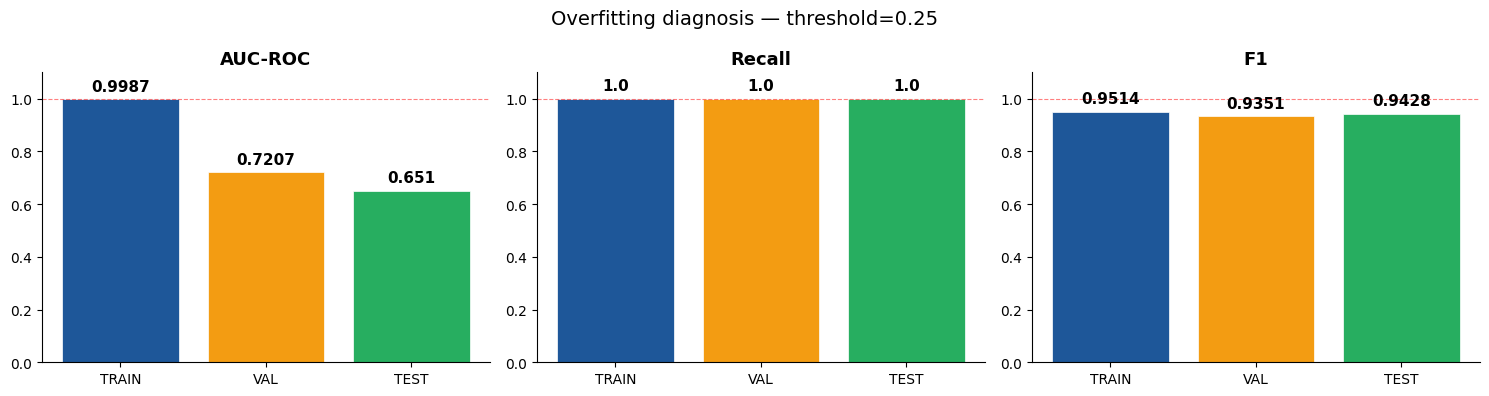

  Gráfico guardado en models/overfitting_diagnosis.png


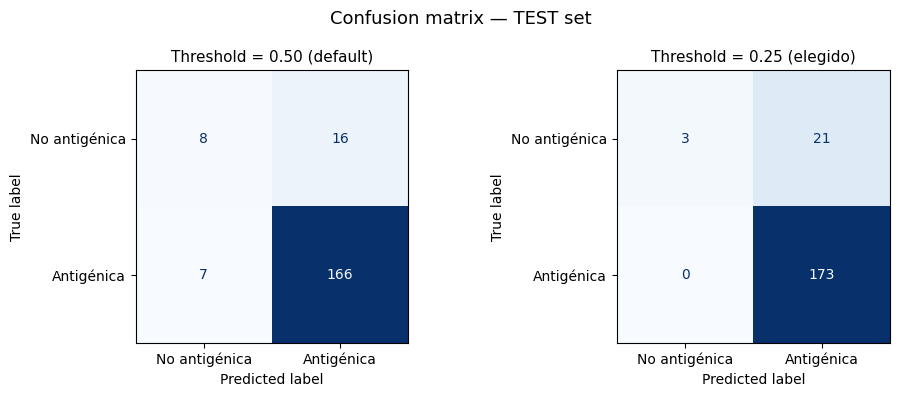

  Matriz guardada en models/confusion_matrix_threshold_comparison.png


In [1]:
# ══════════════════════════════════════════════════════════════
#  DIAGNÓSTICO DE OVERFITTING
#  Añadir al notebook después de entrenar el modelo.
#  Compara métricas en train, validación y test para detectar gap.
# ══════════════════════════════════════════════════════════════

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score,
    precision_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Cargar bundle ──────────────────────────────────────────────
BASE_DIR     = Path('..') 
BUNDLE_PATH  = BASE_DIR / 'models' / 'best_model_mvp.pkl'
DATASET_PATH = BASE_DIR / 'data' / 'processed' / 'dataset.csv'

bundle = joblib.load(BUNDLE_PATH)
model     = bundle['model']
threshold = bundle['threshold']

AMINO_ACIDS  = list('ACDEFGHIKLMNPQRSTVWY')
FEATURE_COLS = (
    ['length', 'molecular_weight', 'isoelectric_point', 'gravy'] +
    [f'aa_{aa}' for aa in AMINO_ACIDS]
)

# ── Reproducir el mismo split que en train_model_mvp.py ───────
from sklearn.model_selection import train_test_split

df = pd.read_csv(DATASET_PATH)
X  = df[FEATURE_COLS].values
y  = df['label'].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15/0.85, stratify=y_trainval, random_state=42
)

# ── Probabilidades en cada split ──────────────────────────────
prob_train = model.predict_proba(X_train)[:, 1]
prob_val   = model.predict_proba(X_val)[:, 1]
prob_test  = model.predict_proba(X_test)[:, 1]

def metricas(y_true, y_prob, thr, nombre):
    y_pred = (y_prob >= thr).astype(int)
    return {
        'Split':      nombre,
        'N':          len(y_true),
        'AUC-ROC':    round(roc_auc_score(y_true, y_prob), 4),
        'Recall':     round(recall_score(y_true, y_pred, zero_division=0), 4),
        'Precision':  round(precision_score(y_true, y_pred, zero_division=0), 4),
        'F1':         round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'FN':         int(((y_true == 1) & (y_pred == 0)).sum()),
        'FP':         int(((y_true == 0) & (y_pred == 1)).sum()),
    }

rows = [
    metricas(y_train, prob_train, threshold, 'TRAIN'),
    metricas(y_val,   prob_val,   threshold, 'VAL'),
    metricas(y_test,  prob_test,  threshold, 'TEST'),
]

results = pd.DataFrame(rows).set_index('Split')
print("=" * 65)
print(f"  DIAGNÓSTICO DE OVERFITTING  (threshold = {threshold})")
print("=" * 65)
print(results.to_string())
print()

# ── Interpretación automática del gap ─────────────────────────
auc_train = results.loc['TRAIN', 'AUC-ROC']
auc_val   = results.loc['VAL',   'AUC-ROC']
auc_test  = results.loc['TEST',  'AUC-ROC']
gap_tv    = round(auc_train - auc_val,  4)
gap_tt    = round(auc_train - auc_test, 4)

print("─" * 65)
print("  ANÁLISIS DEL GAP (AUC-ROC)")
print(f"  Train - Val  : {auc_train} - {auc_val}  = {gap_tv}")
print(f"  Train - Test : {auc_train} - {auc_test} = {gap_tt}")
print()

if gap_tt < 0.05:
    print("  ✅ GAP BAJO  — Sin overfitting significativo.")
elif gap_tt < 0.10:
    print("  ⚠️  GAP MODERADO — Overfitting leve. Aceptable en producción.")
else:
    print("  ❌ GAP ALTO  — Overfitting claro. Considera regularizar o reducir profundidad.")

recall_train = results.loc['TRAIN', 'Recall']
recall_test  = results.loc['TEST',  'Recall']
print()
if recall_train == 1.0 and recall_test == 1.0:
    print("  ℹ️  Recall 1.0 en TRAIN y TEST: puede ser real con threshold=0.25")
    print("     Verifica también con threshold=0.50 para comparar.")
elif recall_train == 1.0 and recall_test < 1.0:
    print(f"  ⚠️  Recall perfecto en TRAIN pero {recall_test} en TEST.")
    print("     El modelo memoriza los positivos de entrenamiento.")
print("─" * 65)

# ── Recall a threshold=0.50 para comparación honesta ──────────
print()
print("  COMPARACIÓN DE THRESHOLDS (solo TEST set)")
print("─" * 65)
for thr in [0.50, 0.40, 0.30, 0.25, 0.20]:
    y_pred = (prob_test >= thr).astype(int)
    fn = int(((y_test == 1) & (y_pred == 0)).sum())
    fp = int(((y_test == 0) & (y_pred == 1)).sum())
    rec = round(recall_score(y_test, y_pred, zero_division=0), 4)
    pre = round(precision_score(y_test, y_pred, zero_division=0), 4)
    f1  = round(f1_score(y_test, y_pred, zero_division=0), 4)
    marker = "  ← elegido" if thr == threshold else ""
    print(f"  thr={thr}  Recall={rec}  Precision={pre}  F1={f1}  FN={fn}  FP={fp}{marker}")

# ── Gráfico: métricas por split ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_to_plot = ['AUC-ROC', 'Recall', 'F1']
colors = {'TRAIN': '#1e5799', 'VAL': '#f39c12', 'TEST': '#27ae60'}

for ax, metric in zip(axes, metrics_to_plot):
    vals = [results.loc[split, metric] for split in ['TRAIN', 'VAL', 'TEST']]
    bars = ax.bar(['TRAIN', 'VAL', 'TEST'], vals,
                  color=[colors[s] for s in ['TRAIN', 'VAL', 'TEST']],
                  edgecolor='white', linewidth=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.spines[['top', 'right']].set_visible(False)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

fig.suptitle(f'Overfitting diagnosis — threshold={threshold}', fontsize=14)
plt.tight_layout()
plt.savefig(BASE_DIR / 'models' / 'overfitting_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Gráfico guardado en models/overfitting_diagnosis.png")

# ── Matriz de confusión en TEST ────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
for ax, thr, title in zip(
    axes2,
    [0.50, threshold],
    ['Threshold = 0.50 (default)', f'Threshold = {threshold} (elegido)']
):
    y_pred = (prob_test >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No antigénica', 'Antigénica'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11)

fig2.suptitle('Confusion matrix — TEST set', fontsize=13)
plt.tight_layout()
plt.savefig(BASE_DIR / 'models' / 'confusion_matrix_threshold_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  Matriz guardada en models/confusion_matrix_threshold_comparison.png")